In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def run_simulation(n_units, n_timesteps, dt, r_neurons_0, W, tau_r, tau_p, I_in, depress_vec):

  r_neurons = np.zeros([n_units, n_timesteps]) #initialize neuron rate array

  r_neurons[:, 0] = r_neurons_0 #initial firing rates

  for i in range(n_timesteps-1):

    I = I_in[:,i].copy() #creates copy of current external input for basis of current input

    I += np.matmul(W * depress_vec[None, :], r_neurons[:, i]) + noise_str * np.random.rand() #applying depression to weight matrix, column scaling of weight matrix, hence weird indexing of depress_arr
                                                                                             #calculating mutual inhibition, adding it to external input, plus noise
    r_inf = F(I) #pass input through nonlinearity

    I_hist[:,i] = r_inf #keep track of combined input

    rdot = 1/tau_r * (r_inf - r_neurons[:, i]) #calculating rate of change for firing rate

    r_neurons[:,i+1] = r_neurons[:, i] + rdot*dt #eulers method to update firing rates

    ddot = 1/tau_p * (depress_rec*(1 - depress_vec) - r_neurons[:, i] * depress_prog * depress_vec) #calculating rate of change for depression vector

    depress_vec += ddot * dt #eulers method to update depression vector

    d_hist[:,i] = depress_vec #keep track of depression history

  return r_neurons, I_hist, d_hist


In [3]:
dt = 0.001 #timestep
T = 10 #simulation duration (s)
t = np.arange(0, T+dt, dt) #create time stamps
n_timesteps = len(t) #number of time steps
n_units = 3 #number of rate units
tau_r = 0.01 #rate time constant
tau_p = 1 #depression time constant
inhib_str = -5 #mutual inhibition
depress_prog = 1 #synaptic depression rate
depress_rec = 1 #depression recovery coefficient
weight_diff = 0.65 #fraction of full inhibition felt by next units
weight_diff_last = 0.6 #fraction of full inhibition felt by last to first units
noise_str = 0.2 #strength of noise

ext_str = 3 #excitation strength
I_ext = np.full([n_units, n_timesteps], float(ext_str)) #uniform tonic excitation, for initial testing

r_neurons_0 = np.zeros(n_units) #initial activity

#create weight matrix
W = np.full([n_units, n_units], float(inhib_str)) #establish matrix of equal weights
np.fill_diagonal(W, 0) #neurons don't inhibit themselves
W[np.eye(n_units, None, -1, bool)] = float(inhib_str)*weight_diff #weights from active unit to next unit weakened
W[0, -1] = float(inhib_str)*weight_diff_last #last unit to first unit weight weakened

#Depression vector
depress_vec = np.ones(n_units) #initialize with 1s

#input nonlinearity
def F(I):
  return np.log(np.maximum(np.zeros(np.shape(I)), I)+1)

#initialize combined input history
I_hist = np.zeros([n_units, n_timesteps])

#initialize depression history
d_hist = np.zeros([n_units, n_timesteps])



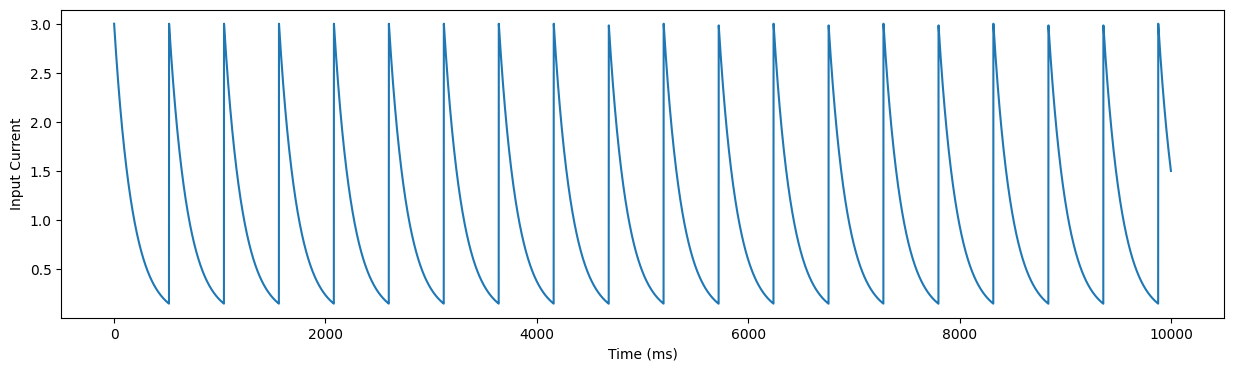

In [11]:
#pulsed input
inscale = 5.2 #2 yields 300 bpm, 2.5 yields 250 bpm, 2.6 yields 240, 5.2 yields 120 bpm, 20 yields 33 bpm (determined through trial and error)
temp1 = ext_str * np.exp(-(30/inscale)*np.mod(t, inscale/10)) #generates pulsed input, with decay scaled such that slower tempi have slower decay.

I_ext_1 = np.tile(temp1, (n_units,1)) #tiles it for input to all units
plt.figure(figsize= (15, 4))
plt.plot(temp1)
plt.xlabel("Time (ms)")
plt.ylabel("Input Current")
plt.show()
#At fast tempi, had floating point errors. Inconsistent peak heights.

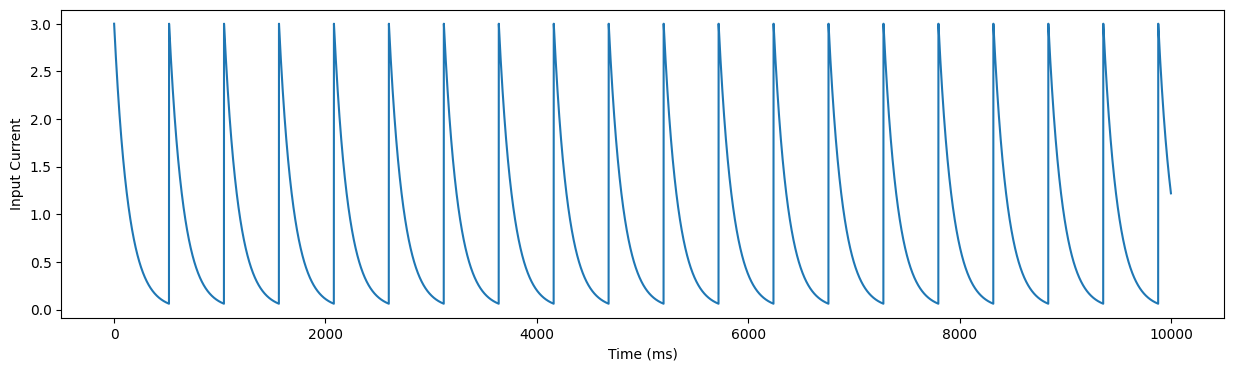

In [5]:
# Almost identical to above, without floating point errors. Consistent peak heights.
phase = (np.arange(len(t)) % int((inscale/10) / dt)) * dt
temp2 = ext_str * np.exp(-(30/4) * phase) #in this case, spike decay time is held constant. More physiologically plausible.

I_ext_2 = np.tile(temp2, (n_units,1))
plt.figure(figsize= (15, 4))
plt.plot(temp2)
plt.xlabel("Time (ms)")
plt.ylabel("Input Current")
plt.show()

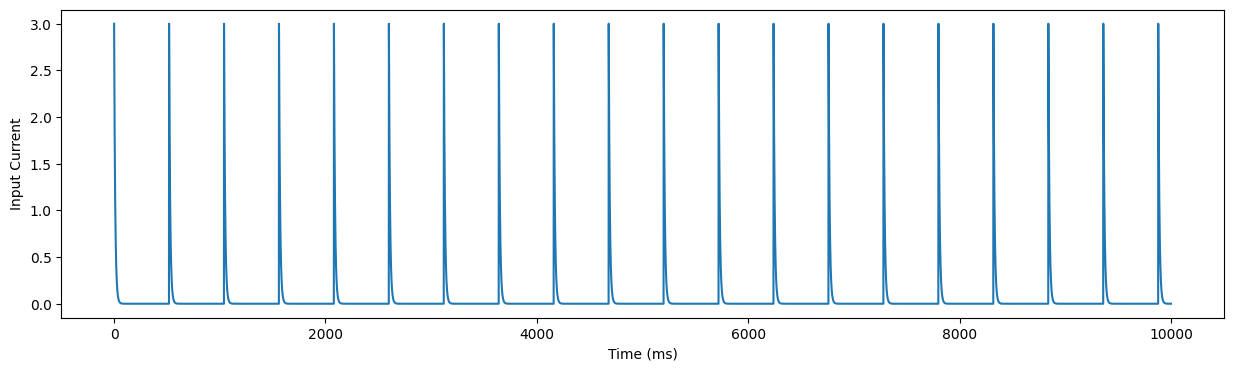

In [6]:
#pulsed input with extremely fast decay, for testing

temp3 = ext_str * np.exp(-100 * phase)
I_ext_3 = np.tile(temp3, (n_units,1))
plt.figure(figsize = (15, 4))
plt.plot(temp3)
plt.xlabel("Time (ms)")
plt.ylabel("Input Current")
plt.show()

In [7]:
#quick calculation to figure out number of spikes in simulation time given bpm, or bpm given number of spikes

bpm = 240
num = 10

numt = bpm / (60 / T)
bpmt = num * (60 / T)

print("num: ", numt)
print("bpm: ", bpmt)

num:  40.0
bpm:  60.0


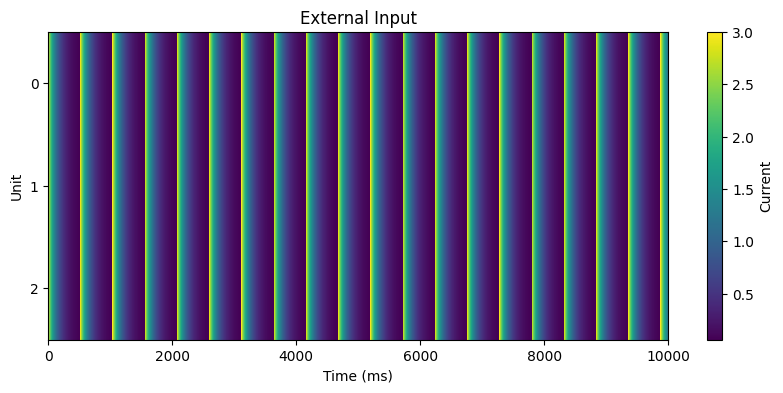

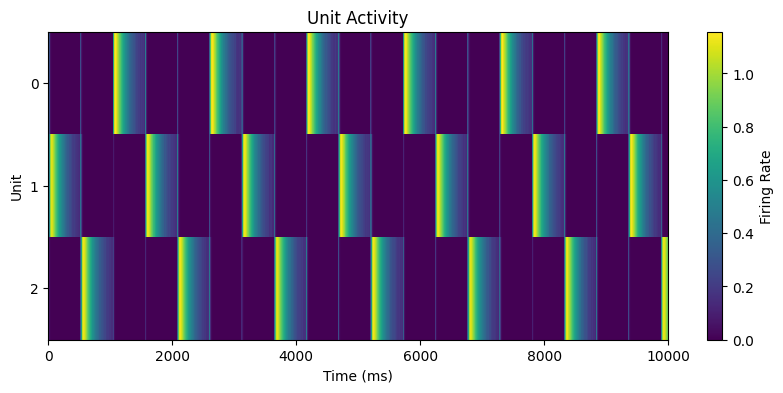

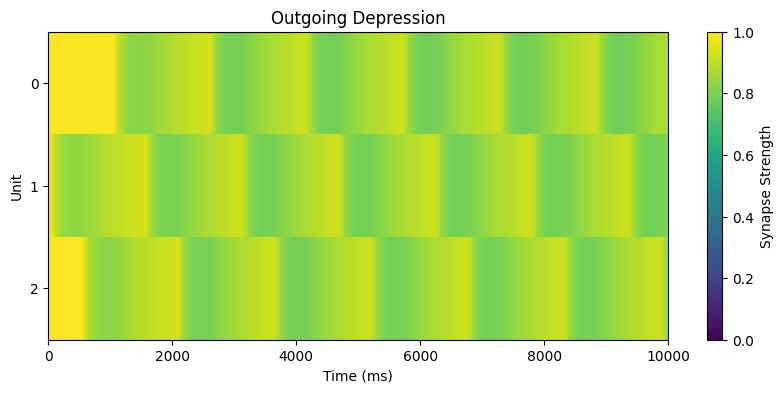

In [8]:
current_input = I_ext_2
r_neurons, I_history, d_history = run_simulation(n_units, n_timesteps, dt, r_neurons_0, W, tau_r, tau_p, current_input, depress_vec)


plt.figure(figsize=(10, 4))
plt.imshow(current_input, interpolation = "none", aspect="auto")
plt.ylabel("Unit")
plt.xlabel("Time (ms)")
plt.yticks(np.arange(0,n_units,1))
plt.colorbar(label="Current")
plt.title("External Input")
plt.show()

# plt.figure(figsize=(20, 4))
# plt.imshow(I_history, interpolation = "none", aspect="auto")
# plt.ylabel("Unit")
# plt.xlabel("Time (ms)")
# plt.yticks(np.arange(0,n_units,1))
# plt.colorbar(label="current")
# plt.title(" Summative Input History")
# plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(r_neurons, interpolation = "none", aspect="auto")
plt.ylabel("Unit")
plt.xlabel("Time (ms)")
plt.yticks(np.arange(0,n_units,1))
plt.colorbar(label="Firing Rate")
plt.title("Unit Activity")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(d_history, interpolation = "none", aspect="auto")
plt.ylabel("Unit")
plt.xlabel("Time (ms)")
plt.yticks(np.arange(0,n_units,1))
plt.colorbar(label="Synapse Strength")
plt.title("Outgoing Depression")
plt.show()

#print(current_input)
#print(r_neurons)
#print(I_history)

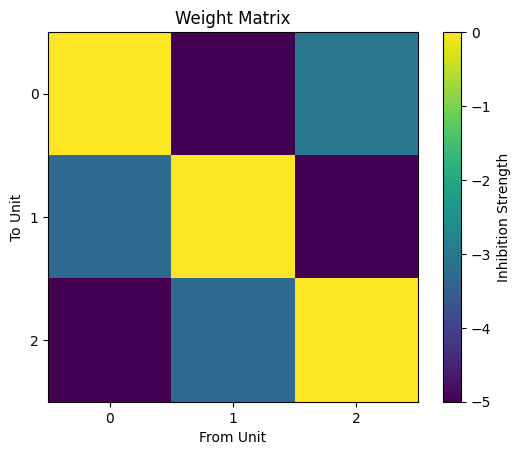

In [9]:
#Visualizing synaptic weights
plt.imshow(W, cmap='viridis', vmin = inhib_str)
plt.title("Weight Matrix")
plt.colorbar(label = "Inhibition Strength")
plt.xlabel("From Unit")
plt.ylabel("To Unit")
plt.xticks(np.arange(0,n_units,1))
plt.yticks(np.arange(0,n_units,1))
plt.show()



In [10]:
# beta = 0.005
# x = range(1000)
# z = 0.5
# zarr = []
# y = 0.5
# yarr = []
# for i in range(1000):
#   zarr.append(z)
#   yarr.append(y)
#   zdot = -beta*z
#   ydot = beta * (1-y)
#   z+= zdot
#   y += ydot
# plt.plot(x, yarr, color = "red")
# plt.plot(x, zarr, color = "green")
# plt.show()